In [37]:
! pip install koreanize_matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
#pd.set_option('display.max_columns', None)  # 모든 열을 표시하도록 설정

In [40]:
# 기본 정보 확인 함수
def show_df_info(df, df_name):
    """
    DataFrame의 기본 정보와 통계 요약을 출력하는 함수
    """
    print(f"\n{df_name} 형태:")
    display(df.shape)
    print(f"\n{df_name} 첫 5행:")
    display(df.head())
    print(f"\n{df_name} 정보:")
    df.info()
    print(f"\n{df_name} 통계 요약:")
    display(df.describe())
    print(f"\n{df_name} 통계 요약:")
    display(df.describe(include = 'O'))
    print(f"\n{df_name} 결측치 확인:")
    display(df.isnull().sum())
    print(f"\n{df_name} 중복값 확인:")
    print(df.duplicated().sum())

# 데이터 불러오기

## course_df

In [41]:
# course_df 
course_df = pd.read_csv('./data/course_df.csv', index_col=0)
course_df.shape

(113, 22)

In [42]:
show_df_info(course_df, 'course_df')


course_df 형태:


(113, 22)


course_df 첫 5행:


,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,중,19:46:00,17:22:00,0,0.143,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,하,19:45:00,17:21:00,0,0.066,1
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,중,19:45:00,17:21:00,0,0.735,1
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,중,19:45:00,17:21:00,0,1.500,1
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,상,19:46:00,17:22:00,0,0.199,1



course_df 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 112
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mountain_name                 113 non-null    object 
 1   course_name                   112 non-null    object 
 2   course_id                     113 non-null    object 
 3   start_point_name              113 non-null    object 
 4   start_point_id                113 non-null    object 
 5   start_lat                     113 non-null    float64
 6   start_lon                     113 non-null    float64
 7   end_point_name                113 non-null    object 
 8   end_point_id                  113 non-null    object 
 9   end_lat                       62 non-null     float64
 10  end_lon                       62 non-null     float64
 11  schedule                      113 non-null    object 
 12  distance_km                   113 non-null    float64


...


course_df 통계 요약:


,mountain_name,course_name,course_id,start_point_name,start_point_id,end_point_name,end_point_id,schedule,attraction_list,difficulty,sunset_summer,sunset_winter
count,113,112,113,113,113,113,113,113,113,113,113,113
unique,10,112,109,85,85,91,94,3,113,6,12,17
top,속리산,수태골∼동봉,JR_10,소공원,SE_ENT_02,속리산 체험학습관,SR_ENT_01,당일,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",중,19:49:00,17:29:00
freq,18,1,2,6,6,5,5,104,1,62,26,17



course_df 결측치 확인:


mountain_name                    0
course_name                      1
course_id                        0
start_point_name                 0
start_point_id                   0
start_lat                        0
start_lon                        0
end_point_name                   0
end_point_id                     0
end_lat                         51
end_lon                         51
schedule                         0
distance_km                      0
duration_min                     0
attraction_list                  0
attraction_count                 0
difficulty                       0
sunset_summer                    0
sunset_winter                    0
shelter_count                    0
dist_to_nearest_parking_km       0
walkable_to_public_transport     0
dtype: int64


course_df 중복값 확인:
0


In [43]:
# null 확인
course_df[course_df.isnull().any(axis = 1)]

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.681390,동봉,PG_EXT_01,NaN,...,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,중,19:46:00,17:22:00,0,0.143,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.590800,가산봉,PG_EXT_02,NaN,...,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,하,19:45:00,17:21:00,0,0.066,1
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.715200,동봉,PG_EXT_01,NaN,...,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,중,19:45:00,17:21:00,0,0.735,1
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.781700,은해봉,PG_EXT_03,NaN,...,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,중,19:45:00,17:21:00,0,1.500,1
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.673950,서봉,PG_EXT_04,NaN,...,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,상,19:46:00,17:22:00,0,0.199,1
5,팔공산,오도암∼비로봉,PG_06,동산탐방지원센터,PG_ENT_06,36.032610,128.683600,비로봉,PG_EXT_05,NaN,...,3.30,150,"오도암, 원효굴, 하늘정원, 비로봉",4,중,19:46:00,17:22:00,0,0.000,1
6,팔공산,탑골∼동봉,PG_07,탑골안내소,PG_ENT_07,35.991060,128.697700,동봉,PG_EXT_01,NaN,...,3.25,125,"케이블카 상부정류장(신림봉), 신림봉 전망대, 낙타봉 전망대, 동봉, 동봉석조약사여래입상",5,상,19:46:00,17:22:00,0,0.566,1
9,계룡산,동학사 1코스 (편도),GR_01,동학사주차장,GR_ENT_01,36.358640,127.238600,관음봉,GR_EXT_01,NaN,...,4.40,150,"동학사 계곡, 동학사, 은선폭포, 관음봉 정상 표지석",4,중,19:52:00,17:26:00,0,0.000,1
11,계룡산,갑사 1코스 (편도),GR_03,갑사주차장,GR_ENT_02,36.372950,127.178100,삼불봉,GR_EXT_02,NaN,...,3.80,150,"갑사 괴목, 갑사 일주문, 오리숲, 갑사, 용문폭포, 신흥암과 천진보탐, 삼불봉",7,중,19:52:00,17:26:00,0,0.000,1
13,계룡산,신원사 1코스 (편도),GR_05,신원사주차장,GR_ENT_03,36.333040,127.180800,연천봉,GR_EXT_03,NaN,...,3.20,290,"신원사, 중악단, 고왕암, 연천봉 석각",4,중,19:52:00,17:26:00,0,0.000,1


In [34]:
# 무등산 course_name null 1개 존재 
course_df[course_df['mountain_name'] == '무등산']

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
79,무등산,새안봉 - 입석대 코스,MD_01,증심사주차장,MD_ENT_01,35.133524,126.951017,서석대,MD_EXT_01,35.119955,...,6.2,210,"새안봉, 약사사, 서인봉, 중머리재, 입석대, 서석대",6,중,19:51,17:31,0,0.0,1
80,무등산,늦재 - 옛길 코스,MD_02,원효사입구,MD_ENT_02,35.146915,126.984946,원효사입구,MD_ENT_02,35.146915,...,10.4,350,"너덜지대, 동화사터, 장불재, 물통거리, 제철유적지, 원효사",6,중,19:51,17:31,0,0.9,1
81,무등산,당산나무 코스,MD_03,증심사주차장,MD_ENT_01,35.133524,126.951017,중머리재,MD_EXT_02,35.117161,...,4.0,95,"증심교, 당산나무, 중머리재,",3,중,19:51,17:31,0,0.0,0
82,무등산,시무기지폭포 코스,MD_04,증심교,MD_ENT_03,35.132253,126.960929,인계리,MD_EXT_03,35.125812,...,12.0,355,"증심교, 새인봉, 토끼등 쉼터, 봉황대, 천제단, 백운암터, 너덜지대, 피안교, 지...",13,중,19:51,17:31,0,999.0,1
83,무등산,너릿재 - 옛길코스,MD_05,너릿재 체육쉼터,MD_ENT_04,35.078972,126.957007,원효사,MD_EXT_04,35.148635,...,14.5,440,"수레바위산, 너와나목장, 중머리재, 입석대, 서석대, 주검동유적, 제철유적지",7,중,19:51,17:31,0,999.0,0
84,무등산,NaN,MD_06,무등산편백자연휴양림,MD_ENT_06,35.093546,127.026777,담양경상리,MD_EXT_05,35.150853,...,14.6,420,"무등산편백자연휴양림, 안양산 전망대, 낙타봉, 장불재, 피안교, 지공너덜, 규봉암,...",9,중,19:51,17:31,0,0.0,0
85,무등산,안양산-북산 코스,MD_07,도원탐방지원센터,MD_ENT_06,35.114467,127.029330,도원마을,MD_EXT_06,35.120433,...,7.5,270,"장불재, 지공너덜, 석불암, 규봉암",4,중,19:51,17:31,0,999.0,0


In [45]:
## 무등산 수정
'''
1. course_name 수정!!
- "새안봉 - 입석대 코스" -> 새인봉으로 수정
- "시무기지폭포 코스" -> 시무지기로 수정
- course_id = MD_06 : 안양산-북산 코스
- course_id = MD_07 : 도원마을-규봉 코스  

2. end_point_name 수정!!
- 한라산 정산분기점 -> 정상으로 수정
'''

# 1. course_name 수정
course_df.loc[course_df['course_name'] == '새안봉 - 입석대 코스', 'course_name'] = '새인봉 - 입석대 코스'
course_df.loc[course_df['course_name'] == '시무기지폭포 코스', 'course_name'] = '시무지기폭포 코스'
course_df.loc[course_df['course_id'] == 'MD_06', 'course_name'] = '안양산-북산 코스'
course_df.loc[course_df['course_id'] == 'MD_07', 'course_name'] = '도원마을-규봉 코스'

# 2. end_point_name 수정
course_df.loc[course_df['end_point_name'] == '한라산 정산분기점', 'end_point_name'] = '한라산 정상분기점'


In [52]:
# 확인1
course_df[course_df['mountain_name'] == '무등산']
# 확인2
course_df[course_df['mountain_name'] == '한라산']['end_point_name']

73    한라산 정상분기점
74    한라산 정상분기점
75        남벽분기점
76        남벽분기점
77         윗세오름
78          어승생
Name: end_point_name, dtype: object

In [ ]:
course_df.isnull().sum() # course_name null 없어짐 확인 

mountain_name                    0
course_name                      0
course_id                        0
start_point_name                 0
start_point_id                   0
start_lat                        0
start_lon                        0
end_point_name                   0
end_point_id                     0
end_lat                         51
end_lon                         51
schedule                         0
distance_km                      0
duration_min                     0
attraction_list                  0
attraction_count                 0
difficulty                       0
sunset_summer                    0
sunset_winter                    0
shelter_count                    0
dist_to_nearest_parking_km       0
walkable_to_public_transport     0
dtype: int64

In [ ]:
# dist_to_nearest_parking_km 출발지에서 가장 가까운 주차장까지 거리가 999인 경우 확인 
course_df[course_df['dist_to_nearest_parking_km'] == 999]

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
54,북한산,사패산코스,BK_03,송추분소,BK_ENT_02,37.713783,126.982295,사패산입구,BK_EXT_03,NaN,...,5.5,180,"사패산, 사패코스, 청동좌불",3,하,20:28,17:52,0,999.0,1
55,북한산,오봉코스,BK_04,송추분소,BK_ENT_02,37.713783,126.982295,오봉탐방지원센터,BK_EXT_04,37.712546,...,6.5,210,"오봉, 여성봉, 민둥바위, 송추폭포",4,하,20:28,17:52,0,999.0,1
59,북한산,백운대코스,BK_08,백운탐방지원센터,BK_ENT_05,37.658401,126.991165,백운대,BK_EXT_01,NaN,...,1.9,90,"도선사, 산악인 추모비, 백운봉암문, 원효봉, 염초봉, 백운대, 인수봉",8,중,20:28,17:53,1,999.0,1
60,북한산,사모바위코스,BK_09,구기탐방지원센터,BK_ENT_06,37.616367,126.961709,사모바위,BK_EXT_08,NaN,...,4.8,150,"문수사, 통천문, 사모바위, 비봉, 승가사, 구기동마애석여래좌상, 석조승가대좌상",7,중,20:28,17:53,0,999.0,1
61,북한산,비봉코스,BK_10,비봉탐방지원센터,BK_ENT_07,37.618235,126.953542,비봉,BK_EXT_09,NaN,...,2.0,60,"목정굴, 금선사, 비봉, 진흥왕순수비유지, 곰바위",5,중,20:28,17:53,0,999.0,1
63,북한산,대동문코스,BK_12,백련공원지킴터,BK_ENT_09,37.645250,127.003851,대동문,BK_EXT_11,NaN,...,2.7,70,"진달래 능선, 용바위, 대동문, 시단봉, 칼바위, 백련사",6,하,20:28,17:53,0,999.0,1
64,북한산,소귀천코스,BK_13,소귀천공원지킴터,BK_ENT_10,37.652963,126.997243,도선사,BK_EXT_12,NaN,...,5.1,190,"드라마촬영지(자이언트), 소귀천 계곡, 대동문, 덕장봉, 동장대, 용암문, 김상궁사리탑",7,중,20:28,17:52,1,999.0,1
82,무등산,시무지기폭포 코스,MD_04,증심교,MD_ENT_03,35.132253,126.960929,인계리,MD_EXT_03,35.125812,...,12.0,355,"증심교, 새인봉, 토끼등 쉼터, 봉황대, 천제단, 백운암터, 너덜지대, 피안교, 지...",13,중,19:51,17:31,0,999.0,1
83,무등산,너릿재 - 옛길코스,MD_05,너릿재 체육쉼터,MD_ENT_04,35.078972,126.957007,원효사,MD_EXT_04,35.148635,...,14.5,440,"수레바위산, 너와나목장, 중머리재, 입석대, 서석대, 주검동유적, 제철유적지",7,중,19:51,17:31,0,999.0,0
85,무등산,도원마을-규봉 코스,MD_07,도원탐방지원센터,MD_ENT_06,35.114467,127.029330,도원마을,MD_EXT_06,35.120433,...,7.5,270,"장불재, 지공너덜, 석불암, 규봉암",4,중,19:51,17:31,0,999.0,0


## infra_df

In [24]:
# infra_df 
infra_df = pd.read_csv('./data/infra_df.csv', index_col=0)
infra_df.shape

(101, 9)

In [25]:
show_df_info(infra_df,'infra_df')


infra_df 형태:


(101, 9)


infra_df 첫 5행:


,place_ID,dist_to_1_foods,dist_to_50_foods,dist_to_70_foods,dist_to_100_foods,dist_to_1_stays,dist_to_10_stays,dist_to_20_stays,dist_to_30_stays
0,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41
1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02
2,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66
3,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43
4,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75



infra_df 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 100
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   place_ID           101 non-null    object 
 1   dist_to_1_foods    101 non-null    float64
 2   dist_to_50_foods   101 non-null    float64
 3   dist_to_70_foods   101 non-null    float64
 4   dist_to_100_foods  101 non-null    float64
 5   dist_to_1_stays    101 non-null    float64
 6   dist_to_10_stays   101 non-null    float64
 7   dist_to_20_stays   101 non-null    float64
 8   dist_to_30_stays   101 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.9+ KB

infra_df 통계 요약:


...


infra_df 통계 요약:


,place_ID
count,101
unique,100
top,MD_ENT_01
freq,2



infra_df 결측치 확인:


place_ID             0
dist_to_1_foods      0
dist_to_50_foods     0
dist_to_70_foods     0
dist_to_100_foods    0
dist_to_1_stays      0
dist_to_10_stays     0
dist_to_20_stays     0
dist_to_30_stays     0
dtype: int64


infra_df 중복값 확인:
1


In [ ]:
infra_df[infra_df.duplicated()] # 무등산 중복값 1행 존재

,place_ID,dist_to_1_foods,dist_to_50_foods,dist_to_70_foods,dist_to_100_foods,dist_to_1_stays,dist_to_10_stays,dist_to_20_stays,dist_to_30_stays
69,MD_ENT_01,0.1,0.5,0.6,0.7,1.2,3.1,3.4,3.6


In [27]:
# 중복값 제거
infra_df = infra_df.drop_duplicates()
infra_df.shape

(100, 9)

# 데이터 merge (course + infra)

In [62]:
# 1. infra_df를 start 기준으로 merge
merged_df = course_df.merge(
    infra_df.add_prefix('start_'),
    left_on='start_point_id',
    right_on='start_place_ID',  # 'start_' prefix를 붙였기 때문에
    how='left'
)

# 2. infra_df를 end 기준으로 merge
merged_df = merged_df.merge(
    infra_df.add_prefix('end_'),
    left_on='end_point_id',
    right_on='end_place_ID',
    how='left'
)

In [63]:
show_df_info(merged_df, 'merged_df')


merged_df 형태:


(113, 40)


merged_df 첫 5행:


,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



merged_df 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mountain_name                 113 non-null    object 
 1   course_name                   113 non-null    object 
 2   course_id                     113 non-null    object 
 3   start_point_name              113 non-null    object 
 4   start_point_id                113 non-null    object 
 5   start_lat                     113 non-null    float64
 6   start_lon                     113 non-null    float64
 7   end_point_name                113 non-null    object 
 8   end_point_id                  113 non-null    object 
 9   end_lat                       62 non-null     float64
 10  end_lon                       62 non-null     float64
 11  schedule                      113 non-null    object 
 12  distance_km                   113 non-null    flo

...


merged_df 통계 요약:


,mountain_name,course_name,course_id,start_point_name,start_point_id,end_point_name,end_point_id,schedule,attraction_list,difficulty,sunset_summer,sunset_winter,start_place_ID,end_place_ID
count,113,113,113,113,113,113,113,113,113,113,113,113,113,37
unique,10,113,109,85,85,90,94,3,113,6,12,17,85,28
top,속리산,수태골∼동봉,JR_10,소공원,SE_ENT_02,속리산 체험학습관,SR_ENT_01,당일,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",중,19:49:00,17:29:00,SE_ENT_02,SR_ENT_01
freq,18,1,2,6,6,5,5,104,1,62,26,17,6,5



merged_df 결측치 확인:


mountain_name                    0
course_name                      0
course_id                        0
start_point_name                 0
start_point_id                   0
start_lat                        0
start_lon                        0
end_point_name                   0
end_point_id                     0
end_lat                         51
end_lon                         51
schedule                         0
distance_km                      0
duration_min                     0
attraction_list                  0
attraction_count                 0
difficulty                       0
sunset_summer                    0
sunset_winter                    0
shelter_count                    0
dist_to_nearest_parking_km       0
walkable_to_public_transport     0
start_place_ID                   0
start_dist_to_1_foods            0
start_dist_to_50_foods           0
start_dist_to_70_foods           0
start_dist_to_100_foods          0
start_dist_to_1_stays            0
start_dist_to_10_sta


merged_df 중복값 확인:
0


- dist_to_nearest_parking_km :  "구할 수 없음", '측정 불가" 의미로 999 로 채워넣은 값 존재!
- end_dist_to_* : 도착지가 산 봉우리인 경우에는 애초에 측정 제외한 것들도 존재..! -> 이거 null 을 모두 999로 채울까?
- end_lat, end_lon : 도착지가 산 봉우리인 경우에는 infra 구하지 않으니 애초에 계산 안함 -> 이거는 null을 모두 -1로 채울까?

In [ ]:
#merged_df.to_csv('./data/merged_df.csv', index=False)

In [60]:
merged_df.head(30)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.681390,동봉,PG_EXT_01,NaN,...,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.590800,가산봉,PG_EXT_02,NaN,...,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.715200,동봉,PG_EXT_01,NaN,...,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.781700,은해봉,PG_EXT_03,NaN,...,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.673950,서봉,PG_EXT_04,NaN,...,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,팔공산,오도암∼비로봉,PG_06,동산탐방지원센터,PG_ENT_06,36.032610,128.683600,비로봉,PG_EXT_05,NaN,...,8.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,팔공산,탑골∼동봉,PG_07,탑골안내소,PG_ENT_07,35.991060,128.697700,동봉,PG_EXT_01,NaN,...,8.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,팔공산,파계사∼파계재,PG_08,파계탐방지원센터,PG_ENT_08,35.993460,128.637800,파계사,PG_EXT_06,36.001470,...,5.44,PG_EXT_06,1.01,2.44,2.53,2.68,1.03,3.44,4.25,5.42
8,팔공산,관암사∼관봉,PG_09,갓바위탐방지원센터,PG_ENT_09,35.971100,128.726200,유스호스텔,PG_EXT_07,35.972270,...,9.43,PG_EXT_07,0.09,3.38,3.62,3.74,0.16,4.07,9.41,9.58
9,계룡산,동학사 1코스 (편도),GR_01,동학사주차장,GR_ENT_01,36.358640,127.238600,관음봉,GR_EXT_01,NaN,...,1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# course_df에서 end_point_id가 있는 개수
print(course_df['end_point_id'].notna().sum()) 

# infra_df에 존재하는 end_point_id가 몇 개인지 확인
print(course_df['end_point_id'].isin(infra_df['place_ID']).sum())


113
37


# EDA 

In [69]:
merged_df.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays'],
      dtype='object')

In [75]:
merged_df['difficulty'].value_counts()

difficulty
중     62
하     27
상     21
중상     1
중하     1
최상     1
Name: count, dtype: int64

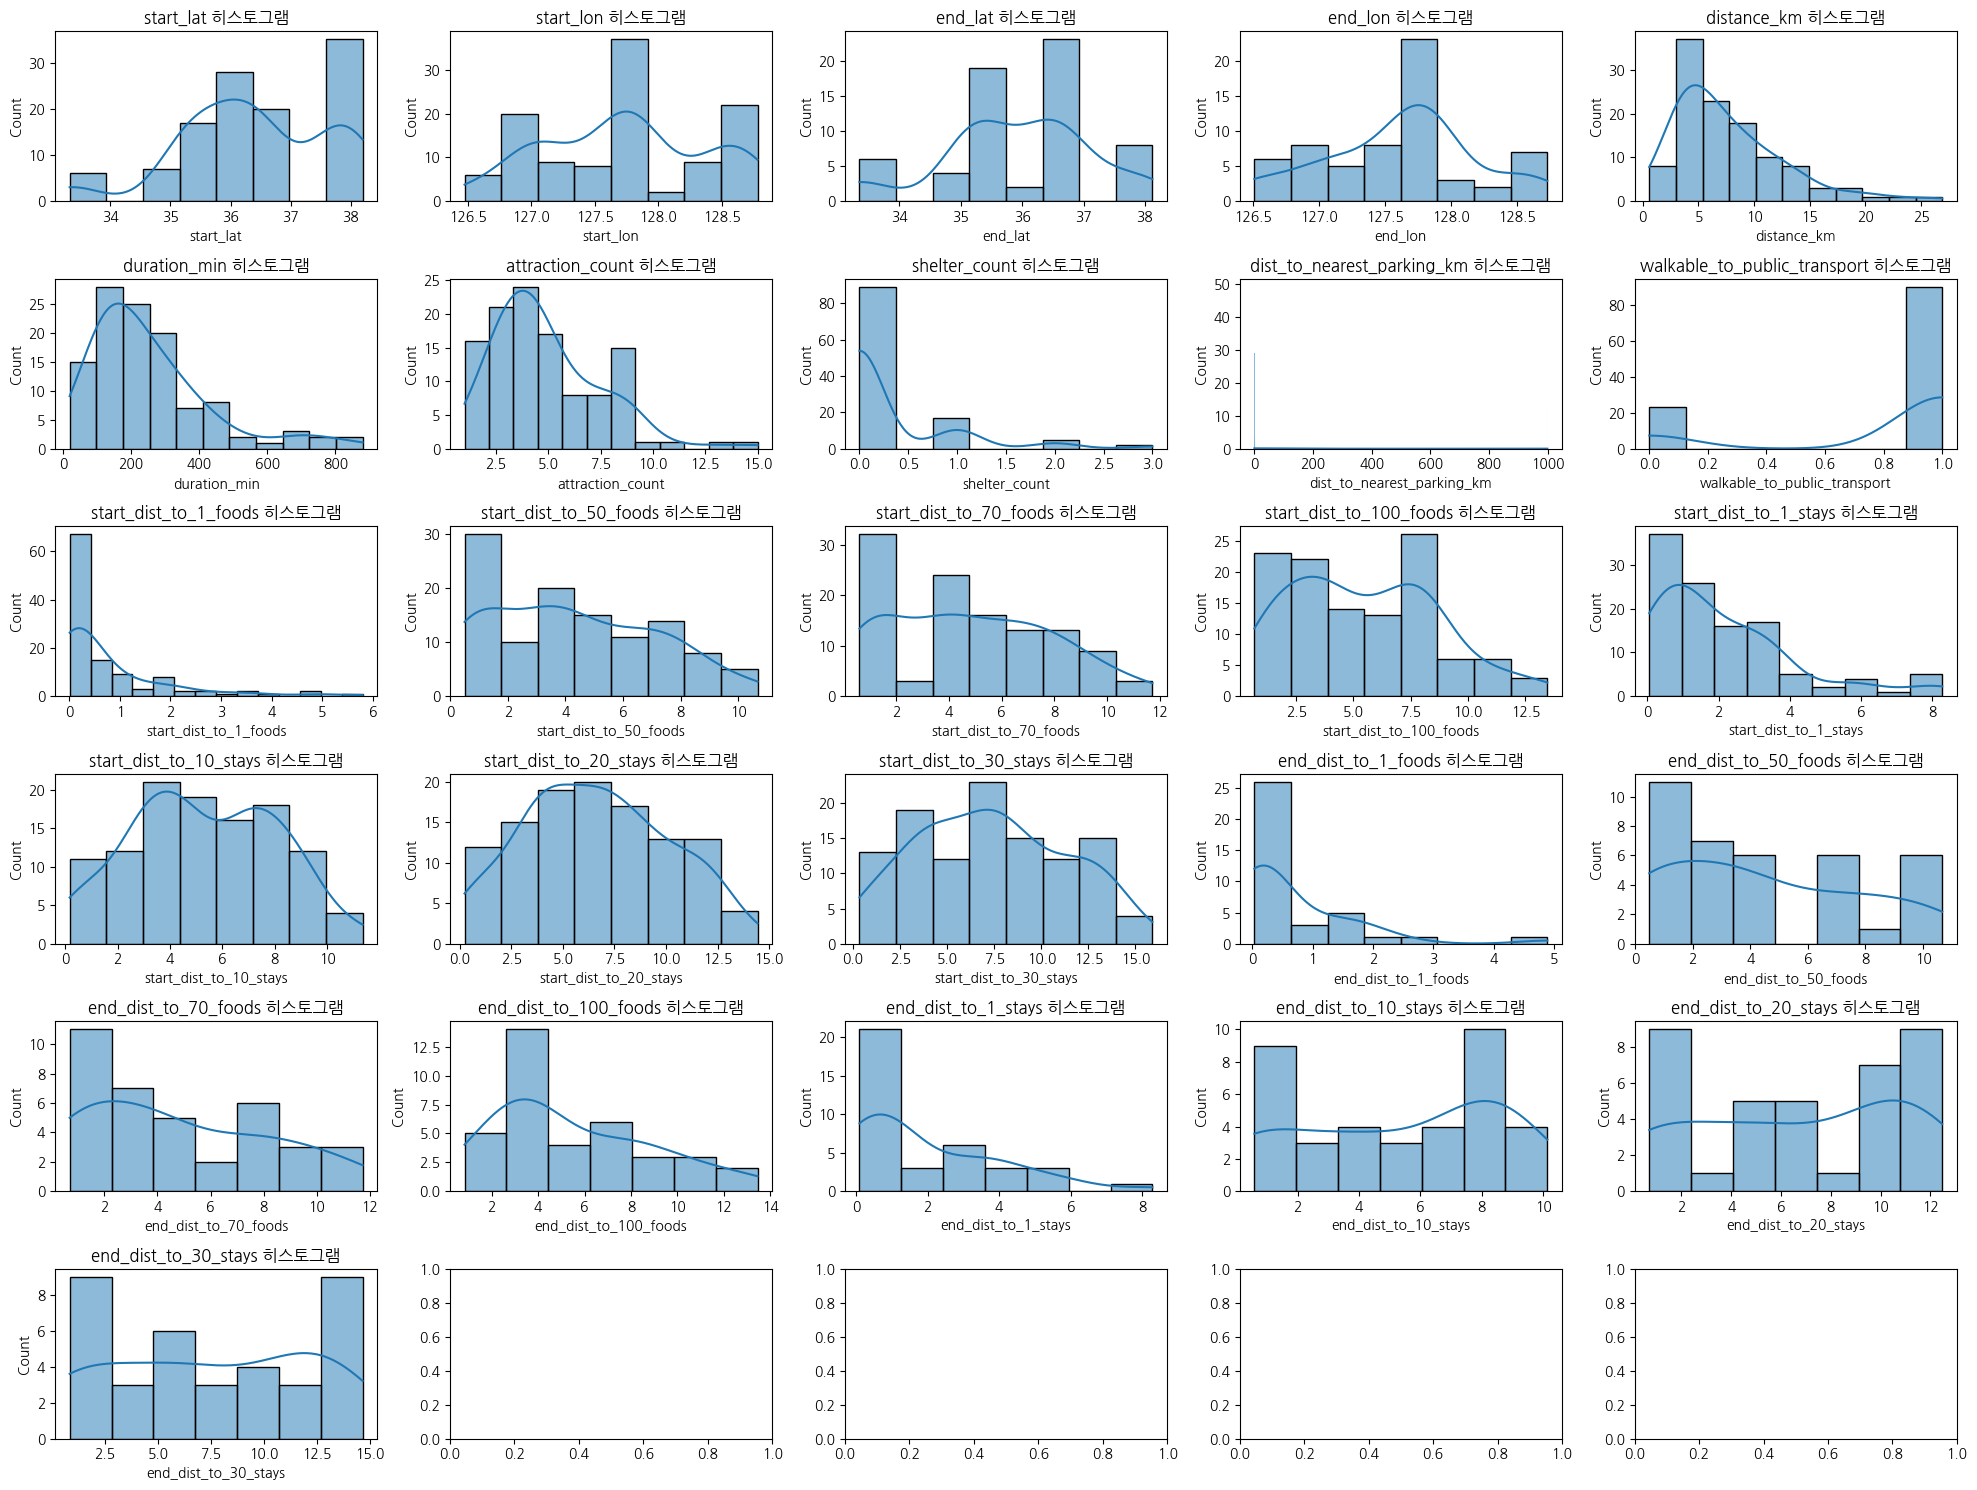

In [72]:
# 각 수치형 변수 데이터 분포 확인
# 히스토그램
target_cols = merged_df.select_dtypes(exclude = 'object').columns

fig, axes = plt.subplots(6,5, figsize = (20,15))

for i, col in enumerate(target_cols):
    sns.histplot(merged_df[col], ax = axes.flat[i], kde = True)
    axes.flat[i].set_title(f'{col} 히스토그램')

fig.tight_layout()
plt.show()

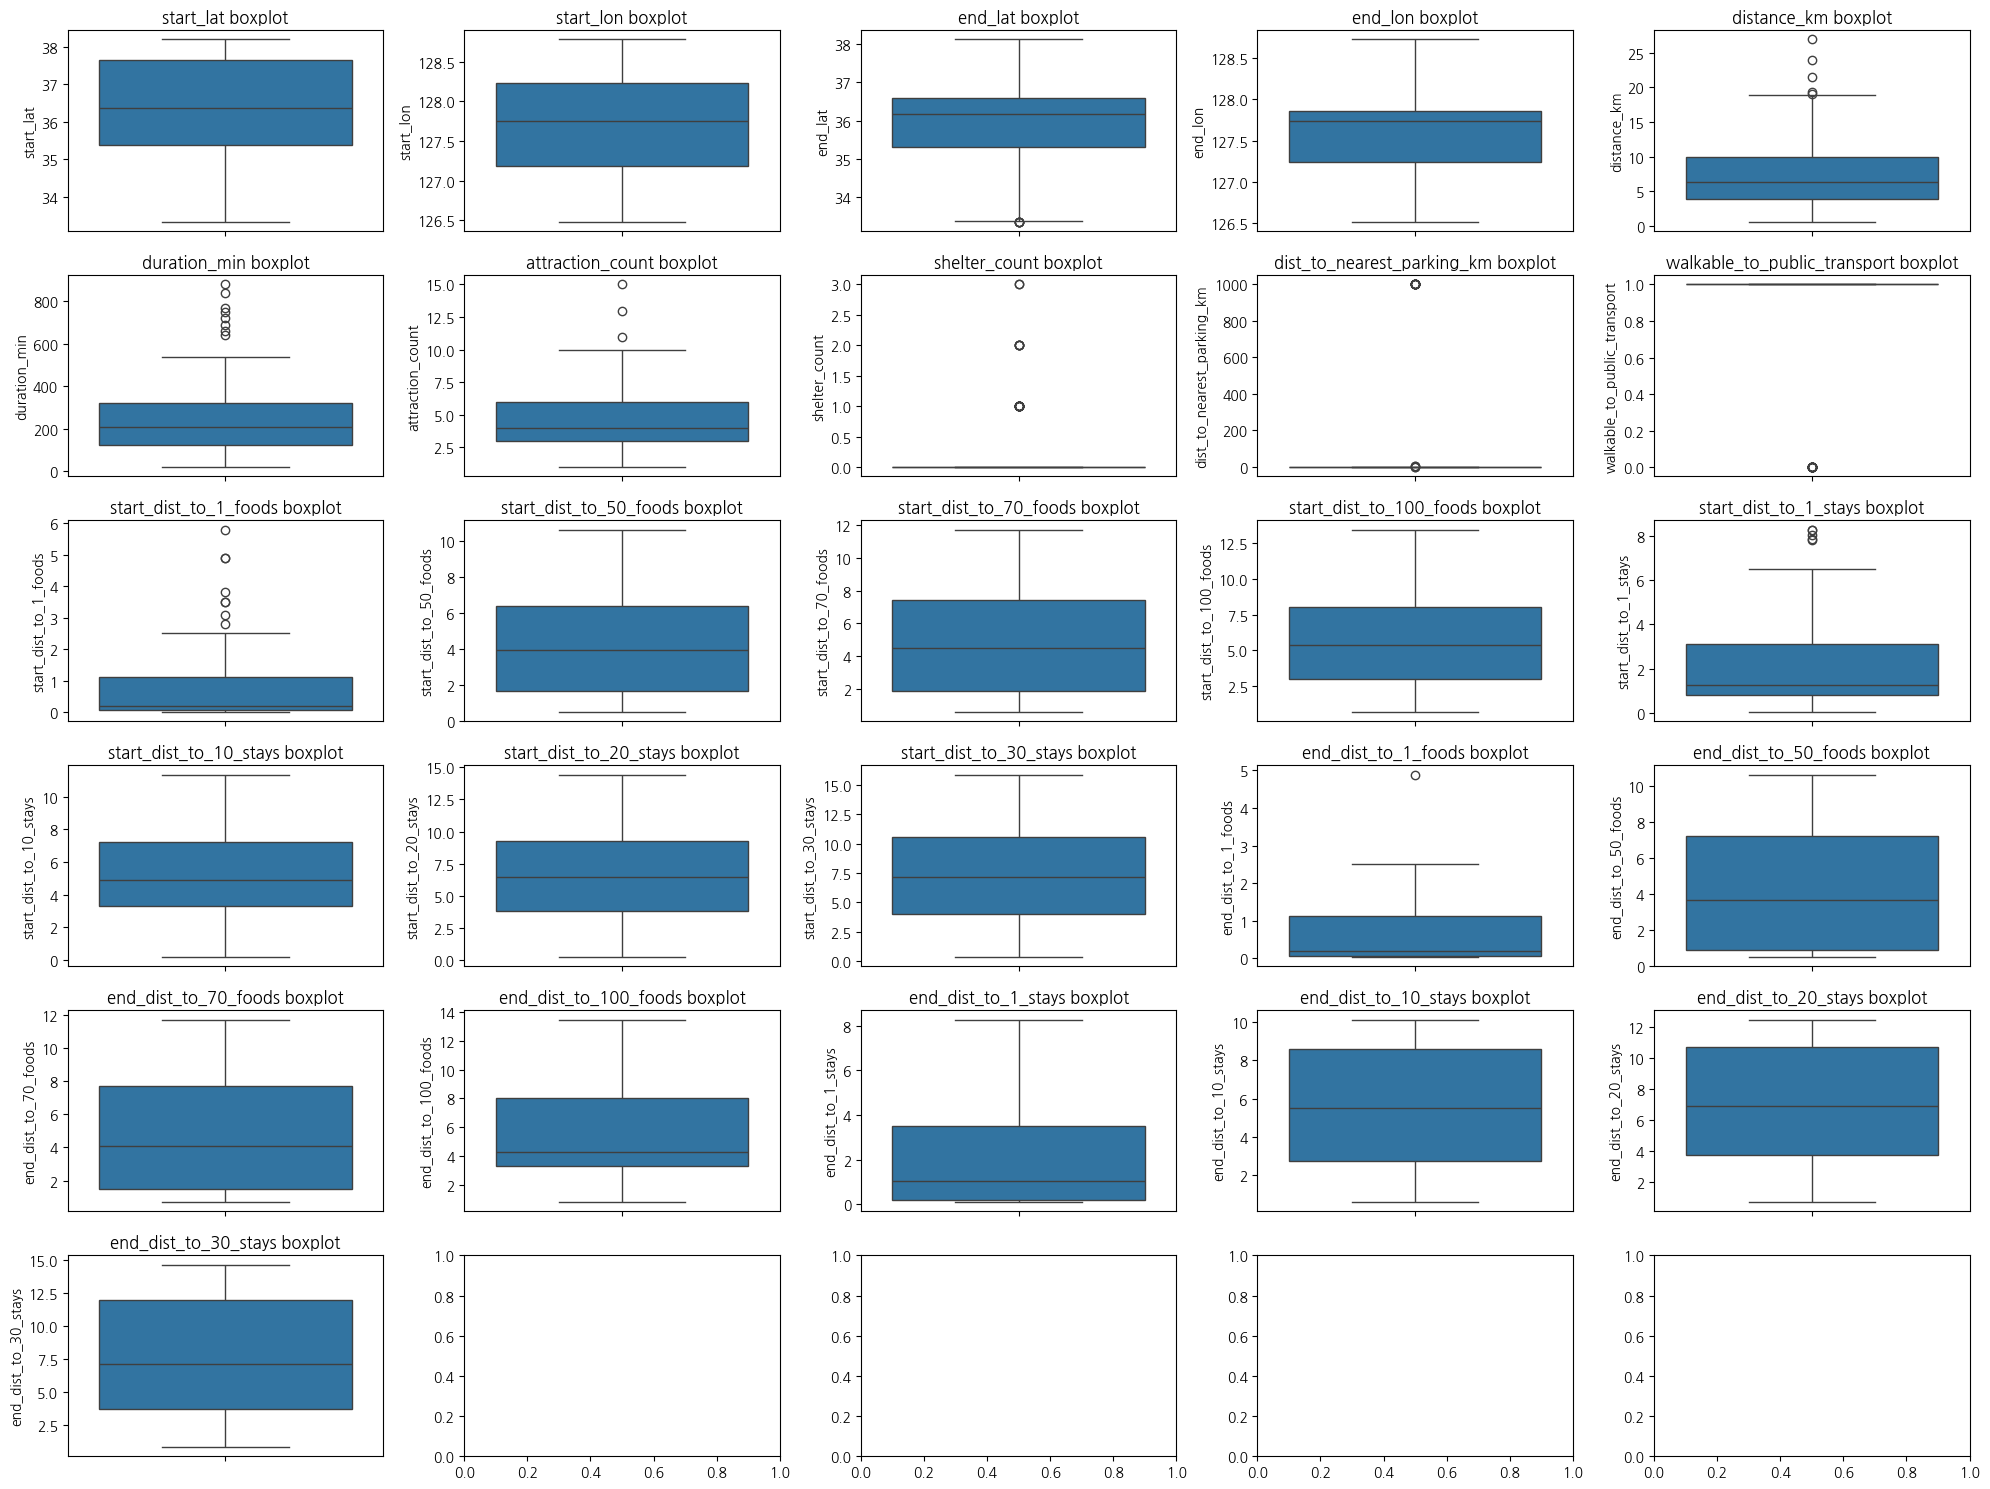

In [73]:
# 이상치 확인
fig, axes = plt.subplots(6,5, figsize = (20,15))

for i, col in enumerate(target_cols):
    sns.boxplot(merged_df[col], ax = axes.flat[i])
    axes.flat[i].set_title(f'{col} boxplot')

fig.tight_layout()
plt.show()

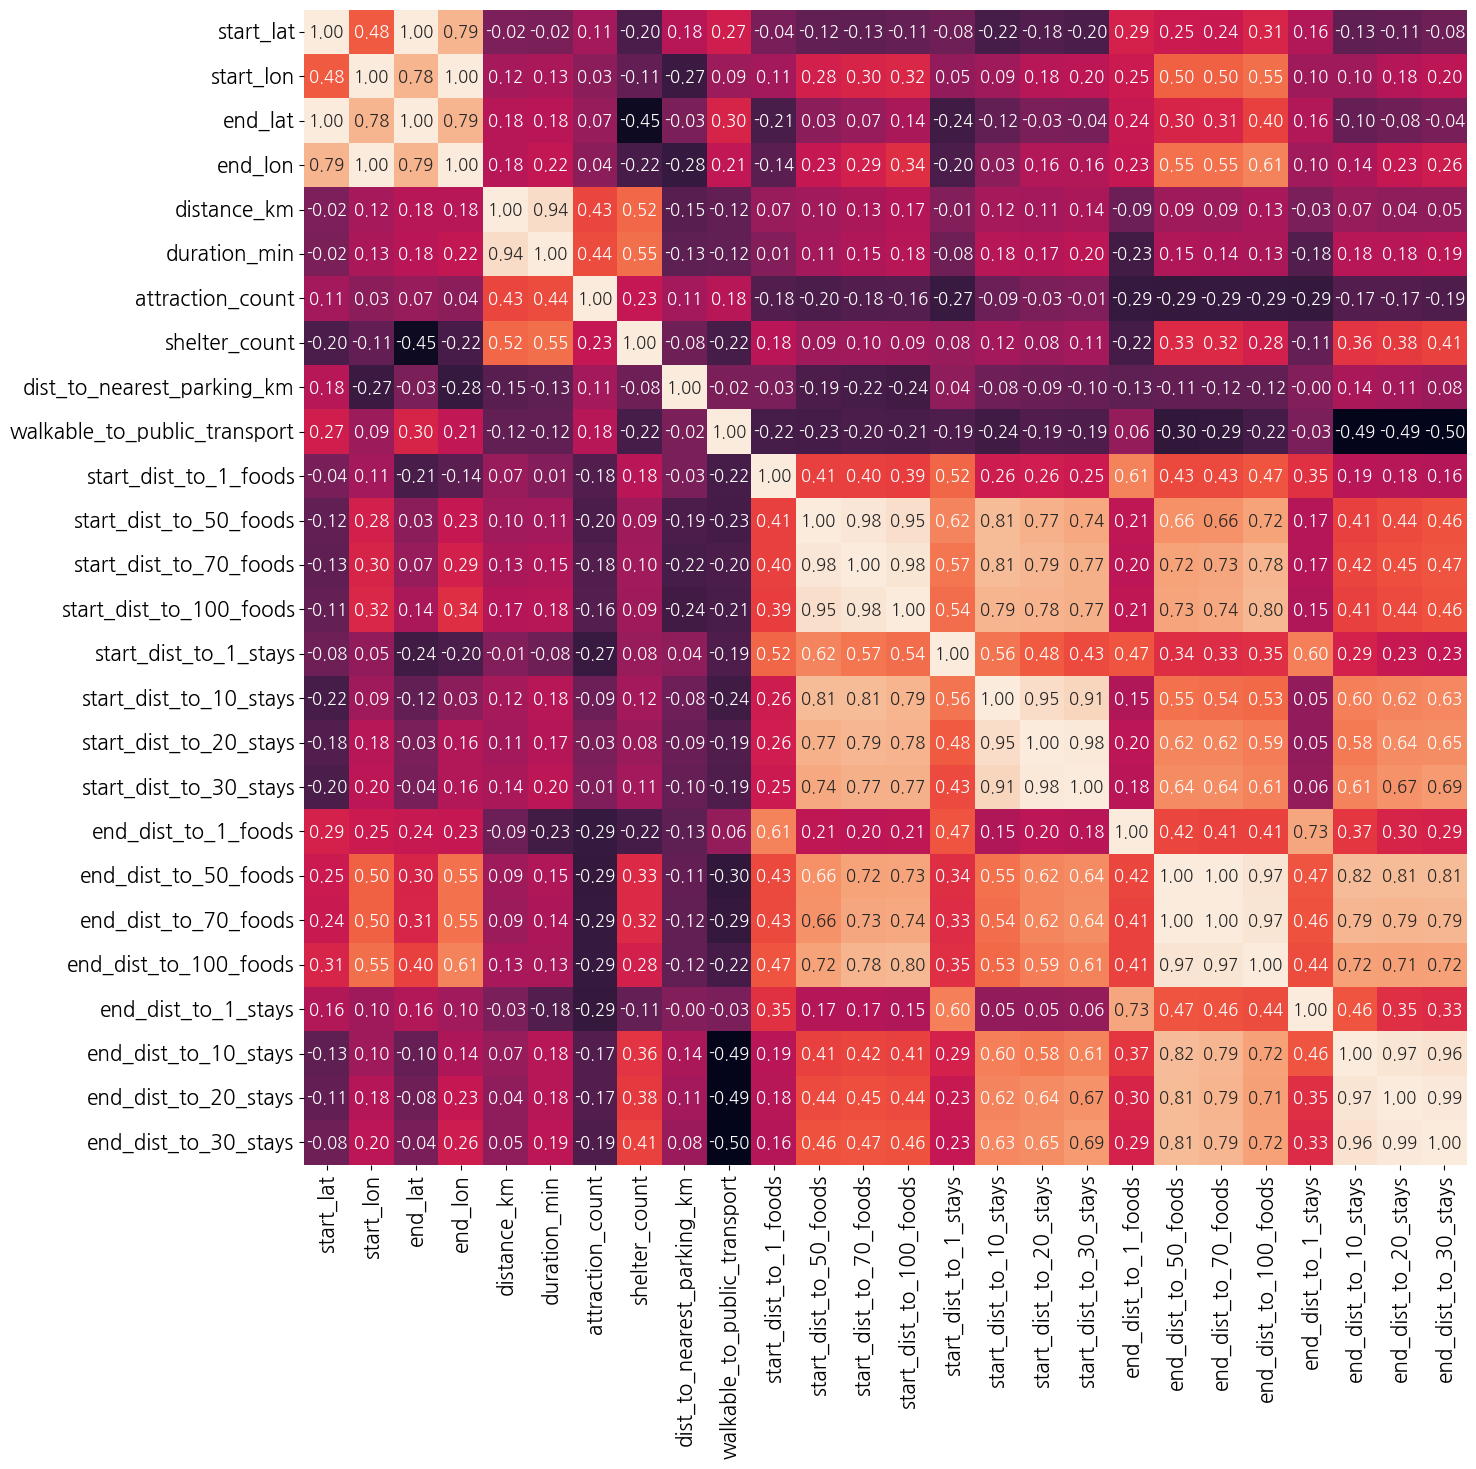

In [78]:
# 상관관계 확인
plt.figure(figsize = (15,15))
sns.heatmap(merged_df[target_cols].corr(), annot = True, annot_kws = {'size': 12},fmt = '.2f', cbar = False)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

- end_lat/lon과 start_lat/lon 끼리 아주 강한 양의 상관 관계 존재
- duration_min & distance_km : 아주 강한 양의 상관 관계
- start_dist_to_* : foods, stays 끼리 아주 강한 양의 상관 관계
- end_dist_to_* : foods, stays 끼리 아주 강한 양의 상관 관계
- start_dist_* 와 end_dist_* 끼리도 강한 양의 상관 관계

# 데이터 처리

In [80]:
# 결측치 처리
cols_to_fill = [
    'end_lat', 'end_lon', 'end_place_ID',
    'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods', 'end_dist_to_100_foods',
    'end_dist_to_1_stays', 'end_dist_to_10_stays', 'end_dist_to_20_stays', 'end_dist_to_30_stays'
]

# 좌표는 -1로, 문자열은 'NONE', 거리 컬럼은 999
merged_df['end_lat'] = merged_df['end_lat'].fillna(-1)
merged_df['end_lon'] = merged_df['end_lon'].fillna(-1)
merged_df['end_place_ID'] = merged_df['end_place_ID'].fillna('NONE')

dist_cols = [col for col in cols_to_fill if 'dist' in col]
merged_df[dist_cols] = merged_df[dist_cols].fillna(999)


In [81]:
merged_df.isnull().sum() # merged_df 결측치 확인

mountain_name                   0
course_name                     0
course_id                       0
start_point_name                0
start_point_id                  0
start_lat                       0
start_lon                       0
end_point_name                  0
end_point_id                    0
end_lat                         0
end_lon                         0
schedule                        0
distance_km                     0
duration_min                    0
attraction_list                 0
attraction_count                0
difficulty                      0
sunset_summer                   0
sunset_winter                   0
shelter_count                   0
dist_to_nearest_parking_km      0
walkable_to_public_transport    0
start_place_ID                  0
start_dist_to_1_foods           0
start_dist_to_50_foods          0
start_dist_to_70_foods          0
start_dist_to_100_foods         0
start_dist_to_1_stays           0
start_dist_to_10_stays          0
start_dist_to_

In [ ]:
# 이상치 확인 함수 
def outliers_idx(df, col):
    q3 = df[col].quantile(0.75)
    q1 = df[col].quantile(0.25)
    
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_check = (df[col] < lower) | (df[col] > upper)
    return outlier_check

# 컬럼별 이상치가 전체 데이터에서 차지하는 비율 확인 (수치형 컬럼만)
original_size = merged_df.shape[0]
outlier_list = []

for col in merged_df[target_cols]:
    outlier_mask = outliers_idx(merged_df, col)
    outlier_cnt = outlier_mask.sum() # 이상치 개수
    ratio = outlier_cnt / original_size * 100 # 이상치 비율

    outlier_list.append(
        {'name' : col,
        'cnt' : outlier_cnt,
        'ratio' : ratio.round(2)}
    )

outlier_df = pd.DataFrame(outlier_list)  # 데이터프레임으로 변환
display(outlier_df.sort_values(by = 'ratio', ascending = False))
outlier_df['ratio'].describe()

,name,cnt,ratio
7,shelter_count,24,21.24
9,walkable_to_public_transport,23,20.35
8,dist_to_nearest_parking_km,17,15.04
5,duration_min,8,7.08
10,start_dist_to_1_foods,8,7.08
14,start_dist_to_1_stays,5,4.42
4,distance_km,5,4.42
6,attraction_count,3,2.65
21,end_dist_to_100_foods,0,0.00
19,end_dist_to_50_foods,0,0.00


count    26.000000
mean      3.164615
std       6.252760
min       0.000000
25%       0.000000
50%       0.000000
75%       3.977500
max      21.240000
Name: ratio, dtype: float64

In [ ]:
merged_df['shelter_count'].value_counts() # 이상치 x, 실제 저 값 / 사실 수치형인데 꼭 범주형으로 보이기도 함

shelter_count
0    89
1    17
2     5
3     2
Name: count, dtype: int64

In [ ]:
merged_df['walkable_to_public_transport'].value_counts() # 애초에 범주형임! 작업할 때부터 0,1로 나누어 넣음

walkable_to_public_transport
1    90
0    23
Name: count, dtype: int64

In [ ]:
merged_df['dist_to_nearest_parking_km'].sort_values(ascending = False).head(20) # 측정할 수 없는 값 '999'로 작성한 상태

55     999.0
63     999.0
54     999.0
94     999.0
95     999.0
85     999.0
100    999.0
83     999.0
82     999.0
64     999.0
61     999.0
60     999.0
59     999.0
49       6.6
106      5.9
25       2.8
46       2.7
23       1.9
47       1.8
24       1.8
Name: dist_to_nearest_parking_km, dtype: float64

# 스케일링

In [90]:
merged_df.select_dtypes(include = 'object').columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'end_point_name', 'end_point_id', 'schedule',
       'attraction_list', 'difficulty', 'sunset_summer', 'sunset_winter',
       'start_place_ID', 'end_place_ID'],
      dtype='object')

In [ ]:
merged_df['schedule'].value_counts() # 1박 2일과 1박2일... 

schedule
당일       104
1박 2일      5
1박2일       4
Name: count, dtype: int64

In [92]:
merged_df['difficulty'].value_counts()

difficulty
중     62
하     27
상     21
중상     1
중하     1
최상     1
Name: count, dtype: int64

In [ ]:
merged_df['sunset_summer'].value_counts() # 시:분:초 형식 차이 

sunset_summer
19:49:00    26
19:50:00    20
19:53:00    14
20:28       13
19:52:00     9
19:51        7
19:46:00     6
20:22        6
19:48        6
19:45:00     3
20:23        2
19:48:00     1
Name: count, dtype: int64